Option Pricing Comparison


,Option Type,Monte Carlo Price,Black-Scholes Price,Absolute Difference
0,European Call,10.473892,10.450584,0.023308
1,European Put,5.574186,5.573526,0.000660


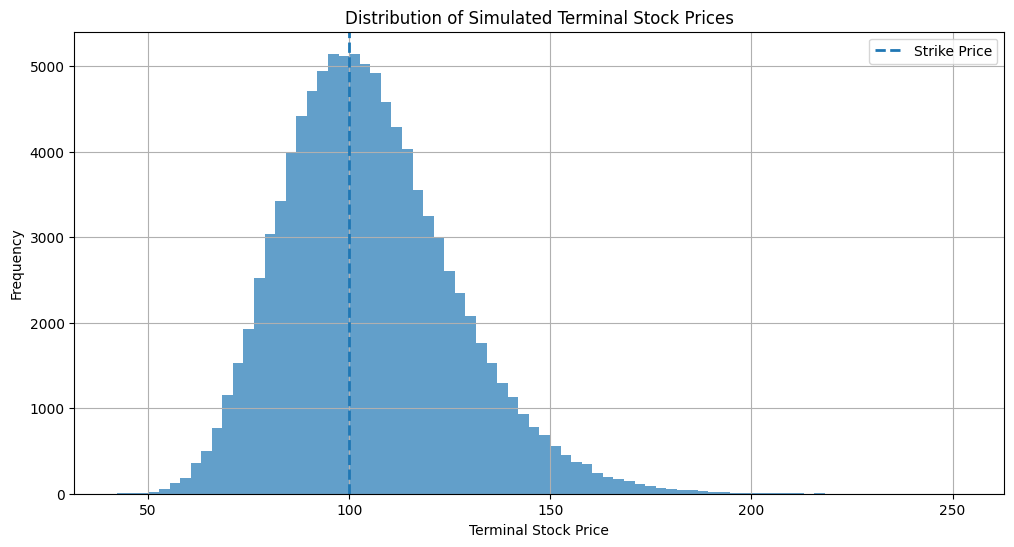

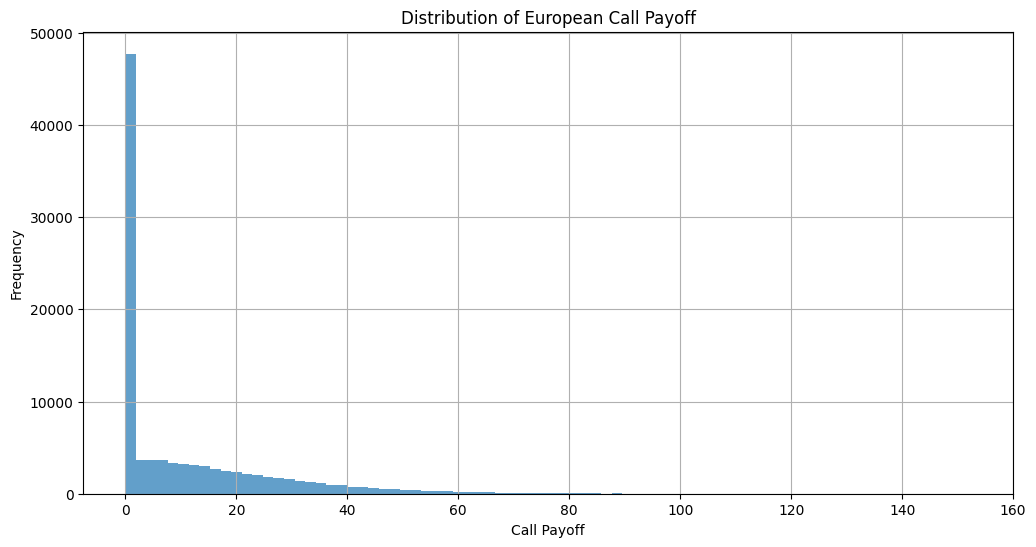

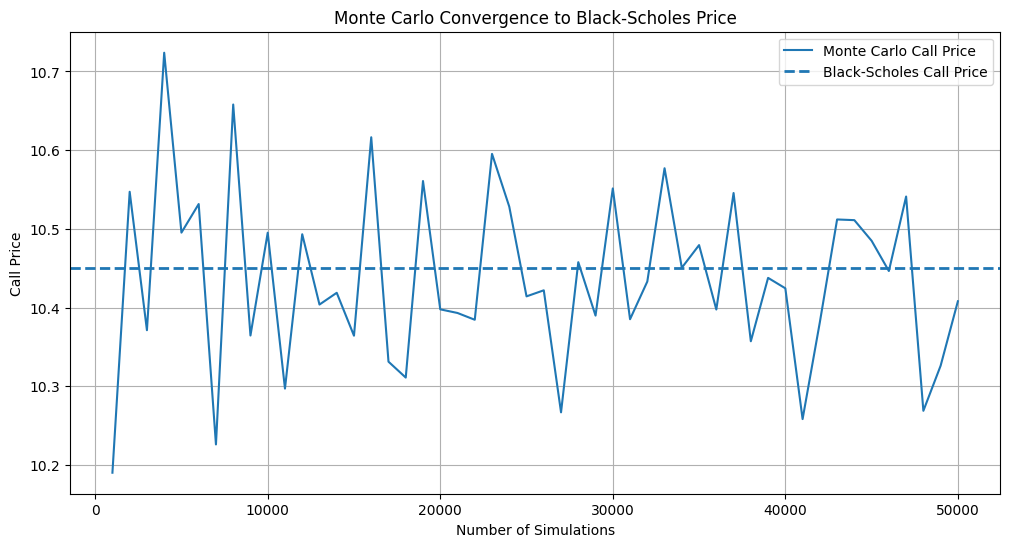

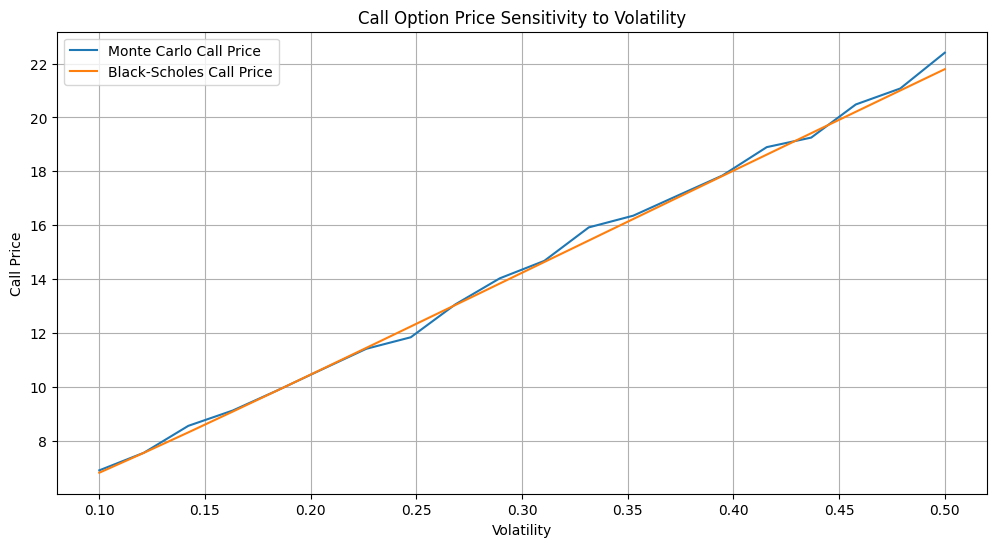

Interpretation:
- Monte Carlo European call price: 10.4739
- Black-Scholes European call price: 10.4506
- Monte Carlo European put price: 5.5742
- Black-Scholes European put price: 5.5735
- The Monte Carlo price should converge toward the Black-Scholes price as the number of simulations increases.
- This project illustrates how simulation-based pricing can be used in financial engineering.


In [1]:
# ============================================
# Monte Carlo Option Pricing
# Author: Giaco237
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# For notebook display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# =========================
# 1. Parameters
# =========================
S0 = 100       # Initial stock price
K = 100        # Strike price
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
T = 1.0        # Time to maturity (years)
N = 100000     # Number of simulations

# =========================
# 2. Simulate terminal stock price
# =========================
Z = np.random.standard_normal(N)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# =========================
# 3. European call and put payoffs
# =========================
call_payoff = np.maximum(ST - K, 0)
put_payoff = np.maximum(K - ST, 0)

# =========================
# 4. Monte Carlo prices
# =========================
mc_call_price = np.exp(-r * T) * np.mean(call_payoff)
mc_put_price = np.exp(-r * T) * np.mean(put_payoff)

# =========================
# 5. Black-Scholes formulas
# =========================
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

bs_call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
bs_put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# =========================
# 6. Price comparison table
# =========================
comparison_df = pd.DataFrame({
    "Option Type": ["European Call", "European Put"],
    "Monte Carlo Price": [mc_call_price, mc_put_price],
    "Black-Scholes Price": [bs_call_price, bs_put_price],
    "Absolute Difference": [
        abs(mc_call_price - bs_call_price),
        abs(mc_put_price - bs_put_price)
    ]
})

print("Option Pricing Comparison")
display(comparison_df)

# =========================
# 7. Histogram of terminal stock prices
# =========================
plt.figure(figsize=(12, 6))
plt.hist(ST, bins=80, alpha=0.7)
plt.axvline(K, linestyle="--", linewidth=2, label="Strike Price")
plt.title("Distribution of Simulated Terminal Stock Prices")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 8. Histogram of call payoff
# =========================
plt.figure(figsize=(12, 6))
plt.hist(call_payoff, bins=80, alpha=0.7)
plt.title("Distribution of European Call Payoff")
plt.xlabel("Call Payoff")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# =========================
# 9. Monte Carlo convergence plot
# =========================
simulation_sizes = np.arange(1000, 50001, 1000)
mc_prices = []

for n in simulation_sizes:
    z_temp = np.random.standard_normal(n)
    st_temp = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_temp)
    payoff_temp = np.maximum(st_temp - K, 0)
    price_temp = np.exp(-r * T) * np.mean(payoff_temp)
    mc_prices.append(price_temp)

plt.figure(figsize=(12, 6))
plt.plot(simulation_sizes, mc_prices, label="Monte Carlo Call Price")
plt.axhline(bs_call_price, linestyle="--", linewidth=2, label="Black-Scholes Call Price")
plt.title("Monte Carlo Convergence to Black-Scholes Price")
plt.xlabel("Number of Simulations")
plt.ylabel("Call Price")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 10. Sensitivity to volatility
# =========================
vol_range = np.linspace(0.10, 0.50, 20)
mc_call_vol_prices = []
bs_call_vol_prices = []

for vol in vol_range:
    z_temp = np.random.standard_normal(N // 10)
    st_temp = S0 * np.exp((r - 0.5 * vol**2) * T + vol * np.sqrt(T) * z_temp)
    payoff_temp = np.maximum(st_temp - K, 0)
    mc_price_temp = np.exp(-r * T) * np.mean(payoff_temp)
    mc_call_vol_prices.append(mc_price_temp)

    d1_temp = (np.log(S0 / K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2_temp = d1_temp - vol * np.sqrt(T)
    bs_price_temp = S0 * norm.cdf(d1_temp) - K * np.exp(-r * T) * norm.cdf(d2_temp)
    bs_call_vol_prices.append(bs_price_temp)

plt.figure(figsize=(12, 6))
plt.plot(vol_range, mc_call_vol_prices, label="Monte Carlo Call Price")
plt.plot(vol_range, bs_call_vol_prices, label="Black-Scholes Call Price")
plt.title("Call Option Price Sensitivity to Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 11. Final interpretation
# =========================
print("Interpretation:")
print(f"- Monte Carlo European call price: {mc_call_price:.4f}")
print(f"- Black-Scholes European call price: {bs_call_price:.4f}")
print(f"- Monte Carlo European put price: {mc_put_price:.4f}")
print(f"- Black-Scholes European put price: {bs_put_price:.4f}")
print("- The Monte Carlo price should converge toward the Black-Scholes price as the number of simulations increases.")
print("- This project illustrates how simulation-based pricing can be used in financial engineering.")